#  MNIST Digit Classification with Neural Network

## IMPORT LIBS

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from google.colab.patches import cv2_imshow
from PIL import Image
import cv2 as cv
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras import backend as K
from tensorflow.math import confusion_matrix

## Loading Data Set

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

Training Data = 60,000 Images
Test Data = 10, 000 Images

Image Dimension --> 28 x 28
Greyscale --> 1 channel

In [5]:
# Printing the tenth Image

In [6]:
print(X_train[10])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  42 118 219 166 118 118   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0 103 242 254 254 254 254 254  66
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0  18 232 254 254 254 254 254 238
   70   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0 104 244 254 224 254 254 254
  141   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0 207 254 210 25

In [7]:
print(X_train[10].shape)

(28, 28)


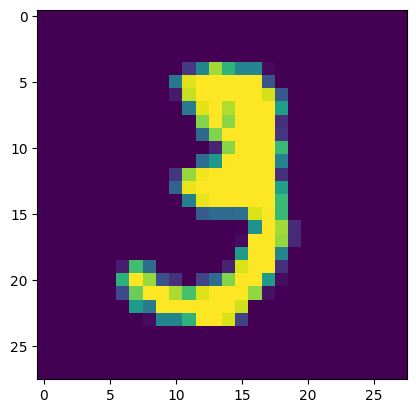

3


In [8]:
# Displying the Image
plt.imshow(X_train[10])
plt.show()

# Print Corresponding Label
print(y_train[10])

Image Labels

In [9]:
# Unique Values in y_train
print(np.unique(y_train))

# Unique Values in y_test
print(np.unique(y_test))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


We can use these labels or onehot encode them

All the Images Have the same dimensions, if not we have to resize all the images to a common dimension

In [10]:
# Scalling the Images
X_train = X_train/255
X_test = X_test/255

# BUILDING THE NEURAL NETWORKS

In [11]:
# Define a sequential neural network model
model = keras.Sequential(
    [
        # Convert the 28x28 input image into a 1D vector (784 features)
        keras.layers.Flatten(input_shape=(28, 28)),

        # First fully connected (dense) hidden layer with ReLU activation
        # Learns nonlinear feature representations
        keras.layers.Dense(50, activation="relu"),

        # Second fully connected hidden layer
        # Adds model capacity to learn more complex patterns
        keras.layers.Dense(50, activation="relu"),

        # Output layer with 10 neurons, one for each class (digits 0–9)
        # Sigmoid outputs class-wise probabilities
        keras.layers.Dense(10, activation="sigmoid")
    ]
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
from keras.src import optimizers
# Compiling The Neural Network
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
# Training The Neural Network
model.fit(X_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8422 - loss: 0.5232
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9547 - loss: 0.1512
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9677 - loss: 0.1093
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9750 - loss: 0.0857
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9792 - loss: 0.0696
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9831 - loss: 0.0578
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9849 - loss: 0.0503
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9869 - loss: 0.0424
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9881 - loss: 0.0372
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9899 - loss: 0.0319


In [14]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9633 - loss: 0.1422
Test Loss: 0.12573736906051636
Test Accuracy: 0.9685999751091003


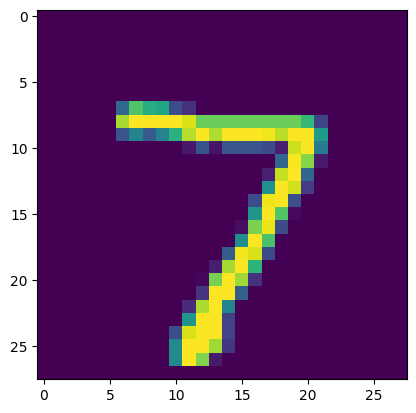

In [15]:
# First Data Point in X_test
plt.imshow(X_test[0])
plt.show()

In [16]:
print(y_test[0])

7


In [17]:
Y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [18]:
print(Y_pred.shape)

(10000, 10)


In [19]:
print(Y_pred[0])

[5.6603352e-07 6.6272983e-06 4.9242761e-02 9.9302560e-01 7.4490408e-06
 3.0895495e-03 4.1829109e-15 9.9999923e-01 2.7234533e-03 1.8505487e-01]


In [20]:
# Converting the prediction probabilities to class
label_for_first_test_image = np.argmax(Y_pred[0])
print(label_for_first_test_image)

7


In [21]:
# Converting the Prediction for all class Labels
y_pred_labels = [np.argmax(i) for i in Y_pred]
print(y_pred_labels)

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(5), np.int64(9), np.int64(0), np.int64(6), np.int64(9), np.int64(0), np.int64(1), np.int64(5), np.int64(9), np.int64(7), np.int64(8), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(0), np.int64(7), np.int64(4), np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(2), np.int64(7), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(7), np.int64(4), np.int64(2), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(6), np.int64(3), np.int64(5), np.int64(5), np.int64(6), np.int64(0), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(3), np.int64(7), np.int64(4), np.int64(6), np.int64(4), np.int64(3), np.int64(0), np.int64(7), np.int64(0), np.int64(2), np.int64(9), np.int64(1), np.int64(7), np.int64(3)

### Confusion Matrix

In [22]:
y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [24]:
conf_mat = confusion_matrix(y_test, y_pred_labels)

In [26]:
conf_mat

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 953,    1,    1,    1,    3,    0,    2,    1,    7,   11],
       [   0, 1119,    2,    4,    3,    1,    2,    1,    3,    0],
       [   3,    2, 1002,    4,    1,    0,    1,   11,    7,    1],
       [   0,    0,    8,  977,    1,    3,    0,    6,    9,    6],
       [   0,    1,    9,    1,  948,    0,    5,    2,    3,   13],
       [   3,    0,    0,   20,    1,  846,    6,    3,    8,    5],
       [   2,    3,    3,    1,    5,    4,  937,    0,    2,    1],
       [   1,    3,    9,    4,   11,    1,    0,  986,    4,    9],
       [   2,    0,    7,    9,    4,    2,    4,    4,  940,    2],
       [   1,    1,    0,    3,   17,    2,    0,    2,    5,  978]],
      dtype=int32)>

Text(0.5, 47.7222222222222, 'Predicted Labels')

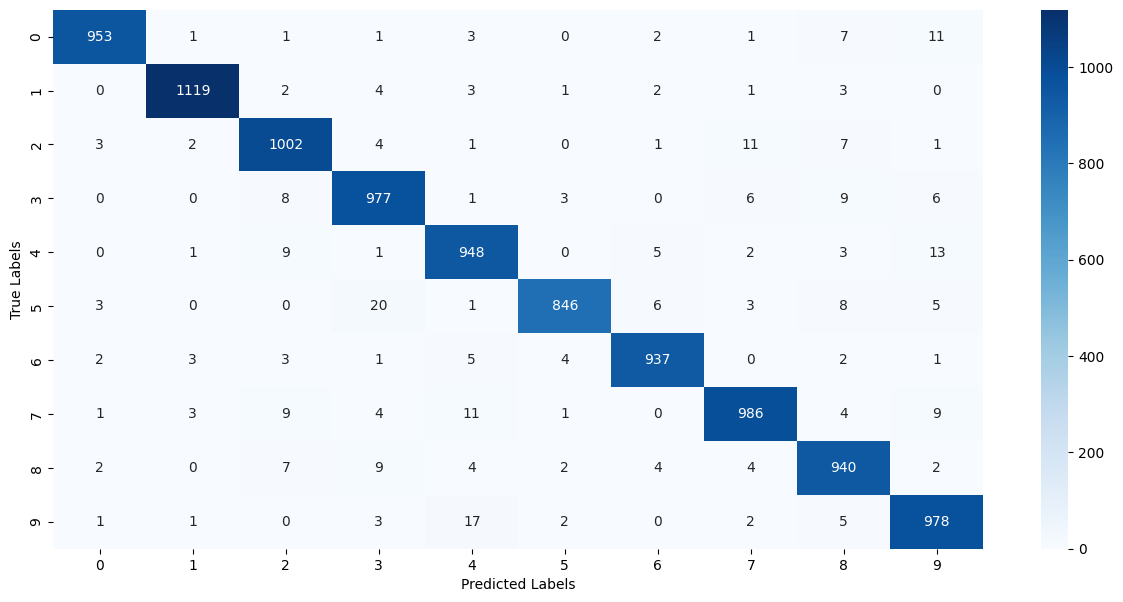

In [27]:
plt.figure(figsize = (15,7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap="Blues")
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')

# BUILDING A PREDICTIVE SYSTEM

In [28]:
# Path to image (Adjust as needed)
input_image_path = "./MNIST_digit.png"
input_image = cv.imread(input_image_path)

In [29]:
type(input_image)

numpy.ndarray

In [30]:
print(input_image)

[[[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 ...

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]]


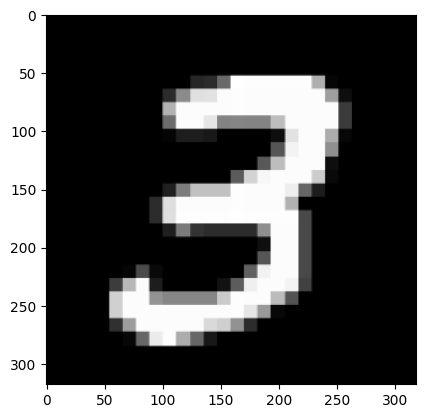

In [32]:
plt.imshow(input_image)

In [33]:
input_image.shape

(318, 318, 3)

In [34]:
# Convert Image To greyscale
greyscale = cv.cvtColor(input_image, cv.COLOR_BGR2GRAY)

In [37]:
greyscale.shape

(318, 318)

In [38]:
# Resizing Image so it fits our Model
input_image_resize = cv.resize(greyscale, (28,28))

In [40]:
input_image_resize.shape

(28, 28)

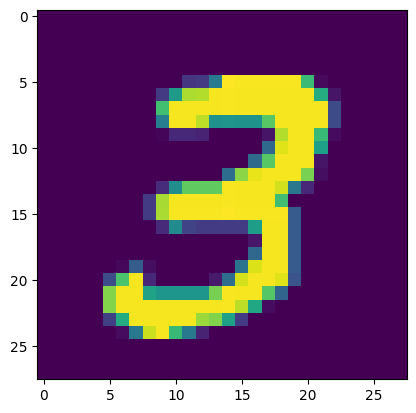

In [41]:
plt.imshow(input_image_resize)

In [42]:
input_image_resize = input_image_resize/255

In [43]:
# Telling The Neural Network we are only Predicting for one Image
image_reshaped = np.reshape(input_image_resize, [1,28,28])

In [44]:
input_prediction = model.predict(image_reshaped)
print(input_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
[[3.2579894e-15 5.7718488e-08 1.4661638e-03 1.0000000e+00 6.2383421e-16
  3.5972081e-02 5.1699802e-21 1.7585730e-03 3.1681638e-02 5.8105871e-02]]


In [45]:
input_pred_label = np.argmax(input_prediction)

In [46]:
input_pred_label

np.int64(3)

# PREDICTIVE SYSTEM

Enter the path of the image: /content/MNIST_digit.png


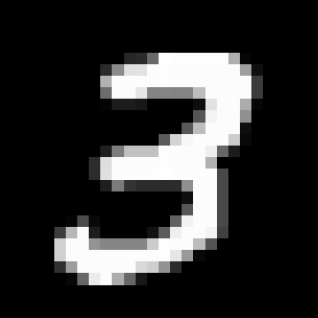

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted Label:  3


In [48]:
# Prompt the user to enter the file path of the input image
input_image_path = input("Enter the path of the image: ")

# Read the image from the specified path
input_image = cv.imread(input_image_path)

# Display the original input image in a window
cv2_imshow(input_image)

# Convert the image from BGR (OpenCV default) to grayscale
# This reduces the image to a single channel, matching the model's training format
greyscale = cv.cvtColor(input_image, cv.COLOR_BGR2GRAY)

# Resize the grayscale image to 28x28 pixels
# This matches the input dimensions expected by the neural network
input_image_resize = cv.resize(greyscale, (28, 28))

# Normalize pixel values to the range [0, 1]
# Improves numerical stability and model performance
input_image_resize = input_image_resize / 255

# Reshape the image to add the batch dimension
# Final shape becomes (1, 28, 28)
image_reshaped = np.reshape(input_image_resize, [1, 28, 28])

# Perform prediction using the trained model
input_prediction = model.predict(image_reshaped)

# Extract the class with the highest predicted probability
input_pred_label = np.argmax(input_prediction)

# Print the predicted class label
print("Predicted Label: ", input_pred_label)